import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
import numpy as np
import matplotlib.pyplot as plt

In [114]:
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Om0=0.3)  # for Imaging Redshifts of BL Lacertae Objects

cosmo = FlatLambdaCDM(H0=73 * u.km / u.s / u.Mpc, Om0=0.3)

In [146]:
def find_distance_modulus(cosmo: FlatLambdaCDM, redshift: float):

    return cosmo.distmod(redshift)

def find_luminosity_distance(cosmo: FlatLambdaCDM, redshift: float):

    return cosmo.luminosity_distance(redshift).to(u.pc)

def find_k4powerlaw(index: float, redshift: float):

    return 2.5*(index-1)*np.log10(1+redshift)

def jester_R_linear(g, r, i):
    return 0.48*g + 0.14*r + 0.38*i - 0.30 # Vega

# Calculate absolute magnitude for my paper

In [134]:
indices = np.array([0,0,1.45,0.8])
z = np.array([2.03, 1.84, 2.04, 2.93])

SDSS_g = np.array([19.08, 18.47, 19.41, 17.57])
SDSS_r = np.array([18.72, 18.28, 18.99, 17.15])
SDSS_i = np.array([18.64, 19.15, 18.57, 16.82])

In [135]:
np.round(find_luminosity_distance(cosmo, z).value,2)

array([1.51749607e+10, 1.34531151e+10, 1.52664589e+10, 2.36948483e+10])

In [136]:
np.round(find_distance_modulus(cosmo, z).value, 2)

array([45.91, 45.64, 45.92, 46.87])

In [137]:
np.round(find_k4powerlaw(indices, z), 2)

array([-1.2 , -1.13,  0.54, -0.3 ])

## Absolute magnitude in SDSS r'

In [131]:
SDSS_r - np.round(find_distance_modulus(cosmo, z).value, 2) - np.round(find_k4powerlaw(indices, z), 2)

array([-25.99, -26.23, -27.47, -29.42])

## Absolute magnitude in R

In [144]:
R = np.round(jester_R_linear(SDSS_g, SDSS_r, SDSS_i),2)
R

array([18.56, 18.4 , 18.73, 16.93])

In [145]:
R - np.round(find_distance_modulus(cosmo, z).value, 2) - np.round(find_k4powerlaw(indices, z), 2)

array([-26.15, -26.11, -27.73, -29.64])

# Reproduce absolute magnitude in Imaging Redshifts of BL Lacertae Objects

## Data from Imaging Redshifts of BL Lacertae Objects

In [109]:
redshifts = np.array([0.559, 0.339, 0.733, 0.298, 0.139, 0.940, 0.247, 0.190, 0.308, 0.188, 0.165, 0.287, 0.512, 1.105, 1.340, 0.314, 0.304, 0.055, 0.896, 0.069, 0.267, 0.125, 0.465, 0.424, 0.315, 0.730, 0.266, 0.138, 0.951, 0.506, 0.548, 0.180, 0.306, 0.638, 0.188, 0.367, 0.344, 0.200, 0.361, 0.031, 0.460, 0.045, 1.048, 0.615, 0.136, 0.130, 0.182, 0.218, 0.164, 0.370, 0.644, 0.141, 0.340, 0.495, 0.152, 0.683, 0.129, 0.162, 0.235, 0.049, 0.702, 1.297, 0.890, 0.312, 0.605, 0.280, 0.055, 0.320, 0.770, 0.407, 0.684, 0.051, 0.664, 0.212, 0.137, 0.048, 0.071, 0.342, 0.053, 1.285, 0.237, 0.069, 0.027, 0.774, 0.190, 0.213, 0.044, 0.165])

paper_nucleus_k = np.array([0.14, 0.10, 0.18, 0.08, 0.04, 0.22, 0.07, 0.06, 0.09, 0.06, 0.05, 0.08, 0.13, 0.24, 0.28, 0.09, 0.09, 0.02, 0.21, 0.02, 0.08, 0.04, 0.12, 0.12, 0.09, 0.18, 0.08, 0.04, 0.22, 0.13, 0.14, 0.05, 0.09, 0.16, 0.06, 0.10, 0.10, 0.06, 0.10, 0.01, 0.12, 0.01, 0.23, 0.16, 0.04, 0.04, 0.05, 0.06, 0.05, 0.10, 0.16, 0.04, 0.10, 0.13, 0.05, 0.17, 0.04, 0.05, 0.07, 0.02, 0.17, 0.27, 0.21, 0.09, 0.15, 0.08, 0.02, 0.09, 0.19, 0.11, 0.17, 0.02, 0.17, 0.06, 0.04, 0.02, 0.02, 0.10, 0.02, 0.27, 0.07, 0.02, 0.01, 0.19, 0.06, 0.06, 0.01, 0.05])

paper_evolution_correction = np.array([-0.43, -0.28, -0.61, -0.24, -0.14, -0.78, -0.21, -0.17, -0.25, -0.17, -0.16, -0.24, -0.40, -0.94, -1.11, -0.26, -0.25, -0.06, -0.74, -0.08, -0.22, -0.13, -0.37, -0.34, -0.26, -0.61, -0.22, -0.14, -0.79, -0.40, -0.43, -0.17, -0.25, -0.50, -0.17, -0.30, -0.28, -0.18, -0.29, -0.03, -0.37, -0.05, -0.88, -0.48, -0.14, -0.13, -0.17, -0.19, -0.16, -0.30, -0.51, -0.14, -0.28, -0.39, -0.15, -0.55, -0.13, -0.15, -0.20, -0.05, -0.58, -1.09, -0.74, -0.25, -0.46, -0.23, -0.06, -0.26, -0.65, -0.33, -0.56, -0.06, -0.53, -0.19, -0.14, -0.05, -0.08, -0.28, -0.06, -1.08, -0.20, -0.08, -0.03, -0.65, -0.17, -0.19, -0.05, -0.16])

observed_nucleus_mag = np.array([15.78, 21.98, 17.68, 18.38, 18.58, 18.18, 19.18, 18.28, 19.03, 18.28, 18.03, 16.08, 19.53, 18.08, 18.20, 17.33, 18.73, 15.28, 15.83, 16.93, 18.23, 17.53, 18.13, 16.58, 17.88, 16.23, 16.03, 15.98, 19.98, 17.78, 18.93, 15.88, 14.99, 20.13, 17.48, 16.08, 21.48, 15.88, 16.48, 13.78, 20.28, 16.15, 17.28, 19.48, 16.38, 14.55, 15.68, 16.89, 18.03, 18.83, 18.51, 17.08, 16.38, 18.84, 15.68, 18.35, 17.38, 16.93, 15.78, 14.48, 16.18, 17.03, 17.88, 19.08, 17.94, 21.08, 16.43, 16.88, 15.83, 18.43, 16.18, 14.95, 18.29, 19.48, 15.30, 15.38, 12.73, 18.03, 19.48, 19.00, 18.21, 13.58, 17.18, 17.53, 16.94, 17.63, 16.83, 17.28])

paper_absolute_nucleus_mag = np.array([-26.96, -19.65, -25.87, -22.72, -20.93, -26.21, -21.86, -22.09, -22.15, -21.74, -21.60, -25.19, -24.44, -26.61, -27.30, -24.28, -22.61, -21.99, -28.30, -20.68, -23.06, -21.54, -25.08, -25.50, -23.40, -27.35, -24.80, -23.28, -24.34, -24.79, -23.84, -24.08, -26.21, -23.04, -22.46, -25.81, -20.02, -24.28, -25.13, -22.49, -22.11, -20.63, -27.44, -23.59, -22.82, -24.64, -24.25, -23.41, -21.63, -23.02, -24.66, -22.25, -25.12, -23.59, -23.82, -24.95, -21.63, -22.75, -24.82, -22.65, -27.24, -28.69, -26.19, -22.27, -25.14, -19.92, -20.81, -24.88, -27.87, -23.52, -27.24, -22.30, -25.07, -20.88, -24.19, -21.85, -25.23, -23.84, -20.12, -26.20, -22.46, -24.82, -18.54, -26.15, -23.24, -22.76, -20.49, -22.37])

In [153]:
paper_absolute_nucleus_mag.min()

-28.69

In [154]:
paper_absolute_nucleus_mag.max()

-18.54

## Calculate nucleus_k 

In [132]:
my_nucleus_k = np.round(find_k4powerlaw(0.7, redshifts),2)

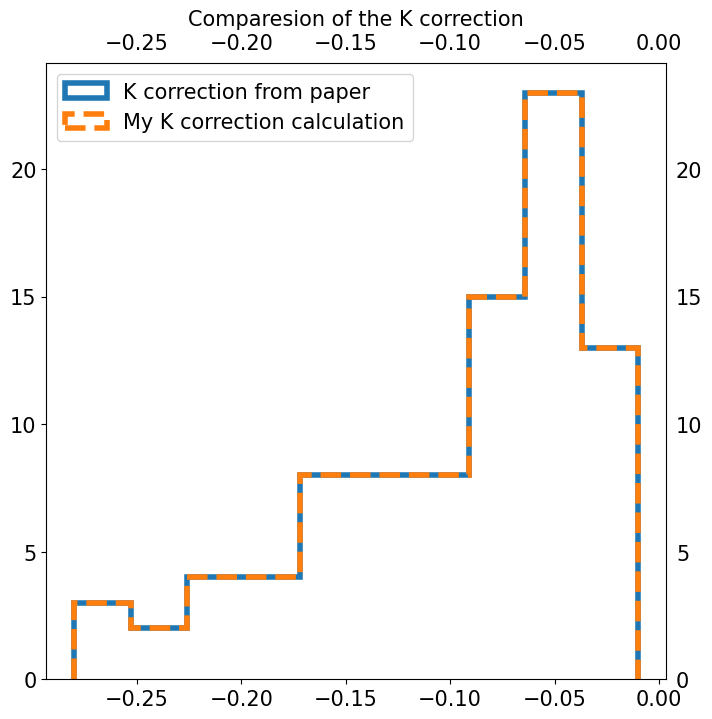

In [149]:
fig, ax = plt.subplots(figsize=(8,8), sharex=False, nrows=1) ##sharex=True

ax.hist(-paper_nucleus_k, label = "K correction from paper", histtype = 'step', linewidth=4.0)
ax.hist(my_nucleus_k, label = "My K correction calculation", histtype = 'step', linewidth=4.0, linestyle = "dashed")

plt.tick_params(axis="both", which="both", labelleft=True, labelright=True, labelbottom=True, labeltop=True, labelsize = 15)

plt.title("Comparesion of the K correction", fontsize = 15)
plt.legend(fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15);


## Calculate absolute magnitudes

In [99]:
my_distance_modulus = np.round(find_distance_modulus(cosmo, redshifts), 2).value
my_distance_modulus

array([42.55, 41.26, 43.27, 40.94, 39.09, 43.93, 40.47, 39.83, 41.02,
       39.81, 39.49, 40.84, 42.32, 44.37, 44.89, 41.07, 40.99, 36.95,
       43.81, 37.46, 40.66, 38.84, 42.07, 41.83, 41.08, 43.26, 40.66,
       39.07, 43.97, 42.29, 42.5 , 39.7 , 41.01, 42.9 , 39.81, 41.46,
       41.3 , 39.96, 41.42, 35.67, 42.04, 36.5 , 44.23, 42.8 , 39.03,
       38.93, 39.73, 40.17, 39.48, 41.49, 42.93, 39.12, 41.27, 42.24,
       39.3 , 43.08, 38.91, 39.45, 40.35, 36.69, 43.15, 44.8 , 43.79,
       41.05, 42.76, 40.78, 36.95, 41.12, 43.4 , 41.73, 43.09, 36.78,
       43.01, 40.1 , 39.05, 36.64, 37.53, 41.29, 36.87, 44.77, 40.37,
       37.46, 35.36, 43.41, 39.83, 40.11, 36.45, 39.49])

In [107]:
my_absolute_nucleus_mag = observed_nucleus_mag - my_distance_modulus - my_nucleus_k# + paper_evolution_correction

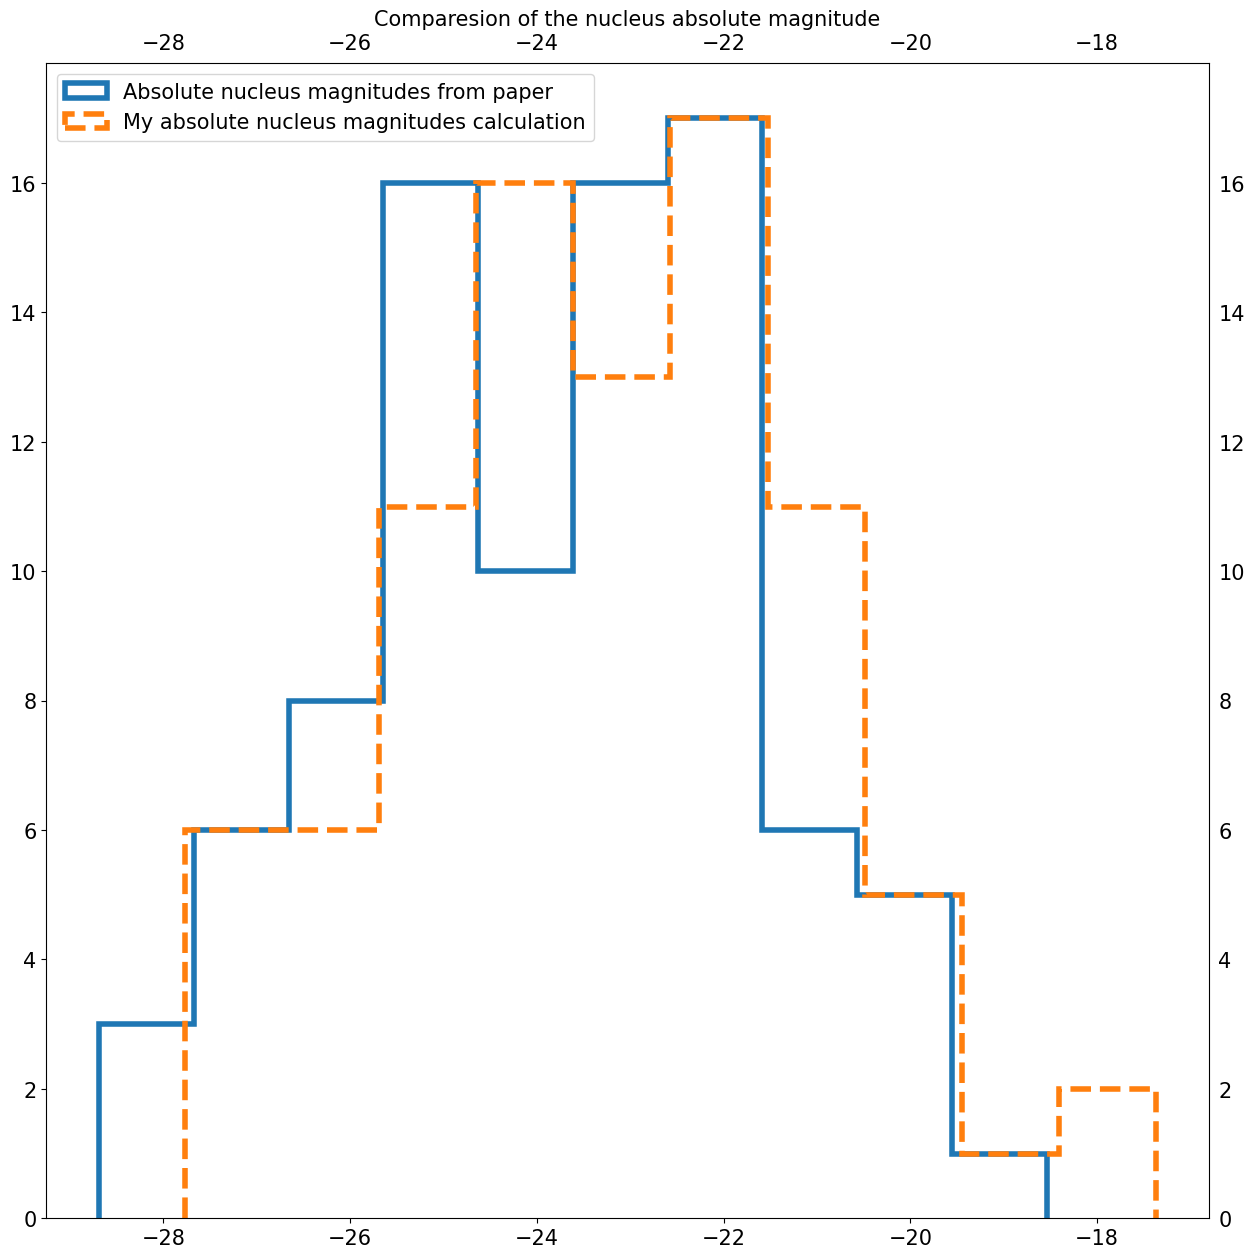

In [148]:
fig, ax = plt.subplots(figsize=(15,15), sharex=False, nrows=1) ##sharex=True

ax.hist(paper_absolute_nucleus_mag, label = "Absolute nucleus magnitudes from paper", histtype = 'step', linewidth=4.0)
ax.hist(my_absolute_nucleus_mag, label = "My absolute nucleus magnitudes calculation", histtype = 'step', linewidth=4.0, linestyle = "dashed")

plt.tick_params(axis="both", which="both", labelleft=True, labelright=True, labelbottom=True, labeltop=True, labelsize = 15)

plt.title("Comparesion of the nucleus absolute magnitude", fontsize = 15)
plt.legend(fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15);


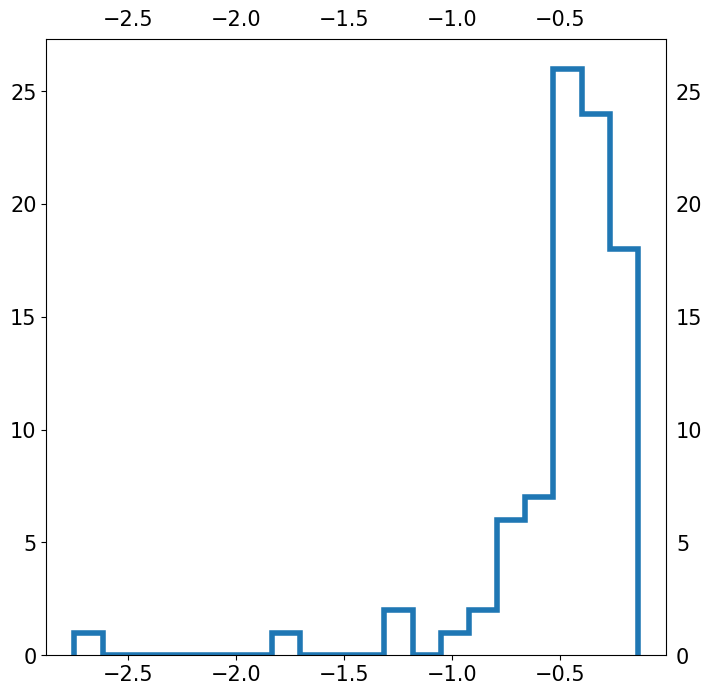

In [152]:
fig, ax = plt.subplots(figsize=(8,8), sharex=False, nrows=1) ##sharex=True

ax.hist(paper_absolute_nucleus_mag-my_absolute_nucleus_mag, bins = 20, label = "offset", histtype = 'step', linewidth=4.0)

plt.tick_params(axis="both", which="both", labelleft=True, labelright=True, labelbottom=True, labeltop=True, labelsize = 15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15);